## 1. Imports

In [1]:
import os
import copy
import random
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    matthews_corrcoef,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
from tqdm import tqdm

## 2. Seed & Device

In [4]:
SEED = 11
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU Name: NVIDIA GeForce RTX 3050 6GB Laptop GPU


## 3. Hyperparameters & Paths

In [ ]:
DATASET_NAME = "Mendeley_Dataset"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.0001
PATIENCE = 30
MIN_DELTA = 0.001
DATASET_PATH = "../../../Dataset/Mendeley_Dataset"

OUTPUT_DIR = f"Results/Mendeley_Dataset/MobileNetV2"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 4. Data Splitting & Stratification

In [6]:
DATASET_PATH = Path(DATASET_PATH)

image_paths = []
labels = []

for class_name in os.listdir(DATASET_PATH):
    class_dir = DATASET_PATH / class_name
    if class_dir.is_dir():
        for img in class_dir.iterdir():
            if img.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                image_paths.append(str(img))
                labels.append(class_name)

CLASS_NAMES = sorted(list(set(labels)))
NUM_CLASSES = len(CLASS_NAMES)
class_to_idx = {class_name: i for i, class_name in enumerate(CLASS_NAMES)}

train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=SEED,
    shuffle=True
)

train_df = pd.DataFrame({'filename': train_paths, 'class': train_labels})
val_df = pd.DataFrame({'filename': val_paths, 'class': val_labels})

class_names = CLASS_NAMES
print("Classes:", class_names)
print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))

Classes: ['Bacteria', 'Fungi', 'Healthy', 'Nematode', 'Pest', 'Phytopthora', 'Virus']
Train samples: 2460
Validation samples: 616


## 5. Dataset & Augmentations

In [7]:
class CustomMinMaxNormalize(object):
    """Custom PyTorch transform for image-specific min-max normalization"""
    def __call__(self, tensor):
        img_min = tensor.min()
        img_max = tensor.max()
        if img_max - img_min == 0:
            return tensor - img_min
        return (tensor - img_min) / (img_max - img_min)

In [8]:
train_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomRotation(degrees=40),
    transforms.RandomResizedCrop(size=IMAGE_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    CustomMinMaxNormalize()
])

val_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    CustomMinMaxNormalize()
])

In [9]:
class MendeleyDataset(Dataset):
    def __init__(self, df, class_to_idx, transform=None):
        self.df = df.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'filename']
        label_name = self.df.loc[idx, 'class']
        label = self.class_to_idx[label_name]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

In [10]:
train_dataset = MendeleyDataset(train_df, class_to_idx, transform=train_transforms)
val_dataset = MendeleyDataset(val_df, class_to_idx, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

## 6. Model Architecture (MobileNetV2)

In [11]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

num_features = base_model.classifier[1].in_features
base_model.classifier[1] = nn.Linear(num_features, NUM_CLASSES)

model = base_model.to(device)

total_trainable_params = count_parameters(model)
print("=" * 40)
print(f"Total Trainable Parameters: {total_trainable_params:,}")
print("=" * 40)

Total Trainable Parameters: 2,232,839


## 7. Loss, Optimizer, Scheduler

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.2, 
    patience=3
)

## 8. Evaluate Function

In [13]:
def evaluate_and_print_metrics(model, val_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    overall_acc = accuracy_score(all_labels, all_preds)
    balanced_acc = balanced_accuracy_score(all_labels, all_preds)
    avg_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    avg_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    avg_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    mcc = matthews_corrcoef(all_labels, all_preds)
    
    cm = confusion_matrix(all_labels, all_preds)
    num_classes = cm.shape[0]
    class_specificities = []
    
    for i in range(num_classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        class_specificities.append(specificity)
        
    avg_specificity = np.mean(class_specificities)

    print("\n================ Validation Metrics ================")
    print(f"Overall Accuracy:                  {overall_acc:.4f}")
    print(f"Balanced Accuracy:                 {balanced_acc:.4f}")
    print(f"Average Precision (Macro):         {avg_precision:.4f}")
    print(f"Average Recall / Sensitivity:      {avg_recall:.4f}")
    print(f"Average Specificity (Macro):       {avg_specificity:.4f}")
    print(f"Average F1-Score (Macro):          {avg_f1:.4f}")
    print(f"Matthews Correlation Coefficient:  {mcc:.4f}")
    print("====================================================\n")

## 9. Training Loop

In [14]:
best_val_loss = float('inf')
best_val_acc = 0
best_val_ep = 0
early_stop_patience = 30
early_stop_counter = 0
min_delta = 0.001

log_history = []
log_csv_path = os.path.join(OUTPUT_DIR, "training_log.csv")

In [15]:
for epoch in tqdm(range(1, EPOCHS + 1)):
    # --- Training Phase ---
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total_train += targets.size(0)
        correct_train += predicted.eq(targets).sum().item()
        
    epoch_train_loss = running_train_loss / total_train
    epoch_train_acc = correct_train / total_train
    
    # --- Validation Phase ---
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
        
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total_val += targets.size(0)
            correct_val += predicted.eq(targets).sum().item()
            
    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = correct_val / total_val

    if(epoch_val_acc > best_val_acc):
        best_val_acc = epoch_val_acc
        best_val_ep = epoch
    
    scheduler.step(epoch_val_loss)
    
    print(f"Epoch {epoch}/{EPOCHS} - loss: {epoch_train_loss:.4f} - val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f} - best: {best_val_acc:.4f} ep {best_val_ep} cnt {early_stop_counter}")
    evaluate_and_print_metrics(model, val_loader, device)
    
    log_history.append({
        'epoch': epoch, 'loss': epoch_train_loss, 'accuracy': epoch_train_acc, 
        'val_loss': epoch_val_loss, 'val_accuracy': epoch_val_acc
    })
    pd.DataFrame(log_history).to_csv(log_csv_path, index=False)
    
    if epoch_val_loss < (best_val_loss - min_delta):
        best_val_loss = epoch_val_loss
        early_stop_counter = 0
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "best.pth"))
        print(f"--> Epoch {epoch}: val_loss improved, saving model to best.pth")
    else:
        early_stop_counter += 1
        if early_stop_counter >= early_stop_patience:
            print(f"Early stopping triggered at epoch {epoch}. Restoring best weights.")
            model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, "best.pth")))
            break

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/100 - loss: 1.1109 - val_loss: 0.6937 - val_accuracy: 0.7484 - best: 0.7484 ep 1 cnt 0


  1%|          | 1/100 [01:11<1:58:40, 71.92s/it]


================ Validation Metrics ================
Overall Accuracy:                  0.7484
Balanced Accuracy:                 0.6630
Average Precision (Macro):         0.7962
Average Recall / Sensitivity:      0.6630
Average Specificity (Macro):       0.9560
Average F1-Score (Macro):          0.6739
Matthews Correlation Coefficient:  0.6995

--> Epoch 1: val_loss improved, saving model to best.pth
Epoch 2/100 - loss: 0.5885 - val_loss: 0.5398 - val_accuracy: 0.8182 - best: 0.8182 ep 2 cnt 0


  2%|▏         | 2/100 [02:23<1:57:28, 71.93s/it]

...


================ Validation Metrics ================
Overall Accuracy:                  0.8685
Balanced Accuracy:                 0.8399
Average Precision (Macro):         0.8435
Average Recall / Sensitivity:      0.8399
Average Specificity (Macro):       0.9776
Average F1-Score (Macro):          0.8372
Matthews Correlation Coefficient:  0.8405

Epoch 44/100 - loss: 0.0805 - val_loss: 0.4530 - val_accuracy: 0.8653 - best: 0.8766 ep 24 cnt 28


 44%|████▍     | 44/100 [49:34<57:46, 61.90s/it]


================ Validation Metrics ================
Overall Accuracy:                  0.8653
Balanced Accuracy:                 0.8502
Average Precision (Macro):         0.8461
Average Recall / Sensitivity:      0.8502
Average Specificity (Macro):       0.9769
Average F1-Score (Macro):          0.8449
Matthews Correlation Coefficient:  0.8366

Epoch 45/100 - loss: 0.0809 - val_loss: 0.4644 - val_accuracy: 0.8571 - best: 0.8766 ep 24 cnt 29


 44%|████▍     | 44/100 [50:34<1:04:22, 68.97s/it]


================ Validation Metrics ================
Overall Accuracy:                  0.8571
Balanced Accuracy:                 0.8157
Average Precision (Macro):         0.8334
Average Recall / Sensitivity:      0.8157
Average Specificity (Macro):       0.9755
Average F1-Score (Macro):          0.8166
Matthews Correlation Coefficient:  0.8269

Early stopping triggered at epoch 45. Restoring best weights.


## 10. Final Evaluation & Metrics

In [16]:
val_loss = 0
correct = 0
total = 0
y_true, y_pred = [], []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())


val_acc = correct / total

In [17]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'
)

mcc = matthews_corrcoef(y_true, y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred)

cm = confusion_matrix(y_true, y_pred)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

results = {
    "accuracy": val_acc,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "mcc": mcc,
    "balanced_accuracy": bal_acc
}

print(results)
print(report)

{'accuracy': 0.8701298701298701, 'precision': 0.8716415398262645, 'recall': 0.8701298701298701, 'f1': 0.8693191938257241, 'mcc': 0.8419024880495346, 'balanced_accuracy': 0.8182782681452333}
              precision    recall  f1-score   support

    Bacteria       0.94      0.98      0.96       114
       Fungi       0.88      0.84      0.86       150
     Healthy       0.72      0.82      0.77        40
    Nematode       0.78      0.50      0.61        14
        Pest       0.82      0.89      0.85       122
 Phytopthora       0.88      0.83      0.85        69
       Virus       0.91      0.87      0.89       107

    accuracy                           0.87       616
   macro avg       0.85      0.82      0.83       616
weighted avg       0.87      0.87      0.87       616



## 11. Save Results

In [18]:
pd.DataFrame(log_history).to_csv(f"{OUTPUT_DIR}/history.csv", index=False)
pd.DataFrame([results]).to_csv(f"{OUTPUT_DIR}/summary.csv", index=False)

with open(f"{OUTPUT_DIR}/results.json", "w") as f:
    json.dump(results, f, indent=4)

with open(f"{OUTPUT_DIR}/report.txt", "w") as f:
    f.write(report)

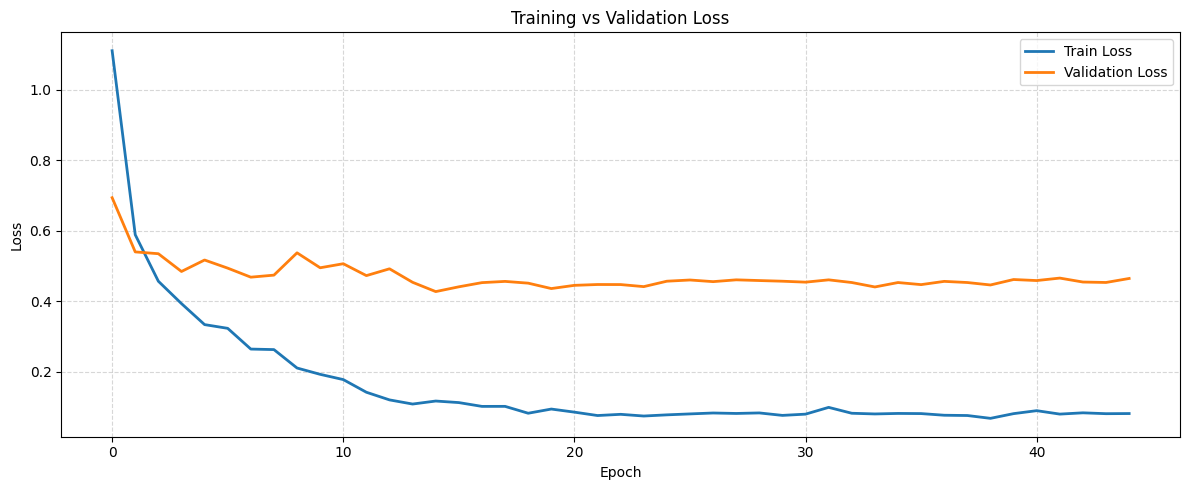

In [19]:
train_loss = [epoch["loss"] for epoch in log_history]
val_loss = [epoch["val_loss"] for epoch in log_history]

plt.figure(figsize=(12, 5))
plt.plot(train_loss, label="Train Loss", linewidth=2)
plt.plot(val_loss, label="Validation Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/loss_curve.png", dpi=300)
plt.show()

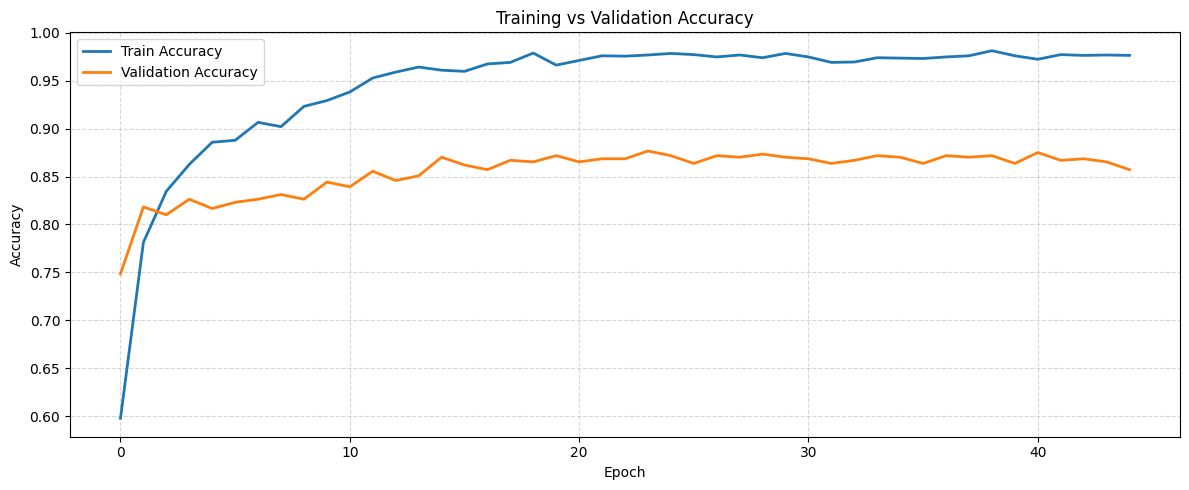

In [20]:
train_acc = [epoch["accuracy"] for epoch in log_history]
val_acc = [epoch["val_accuracy"] for epoch in log_history]

plt.figure(figsize=(12, 5))
plt.plot(train_acc, label="Train Accuracy", linewidth=2)
plt.plot(val_acc, label="Validation Accuracy", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/acc_curve.png", dpi=300)
plt.show()

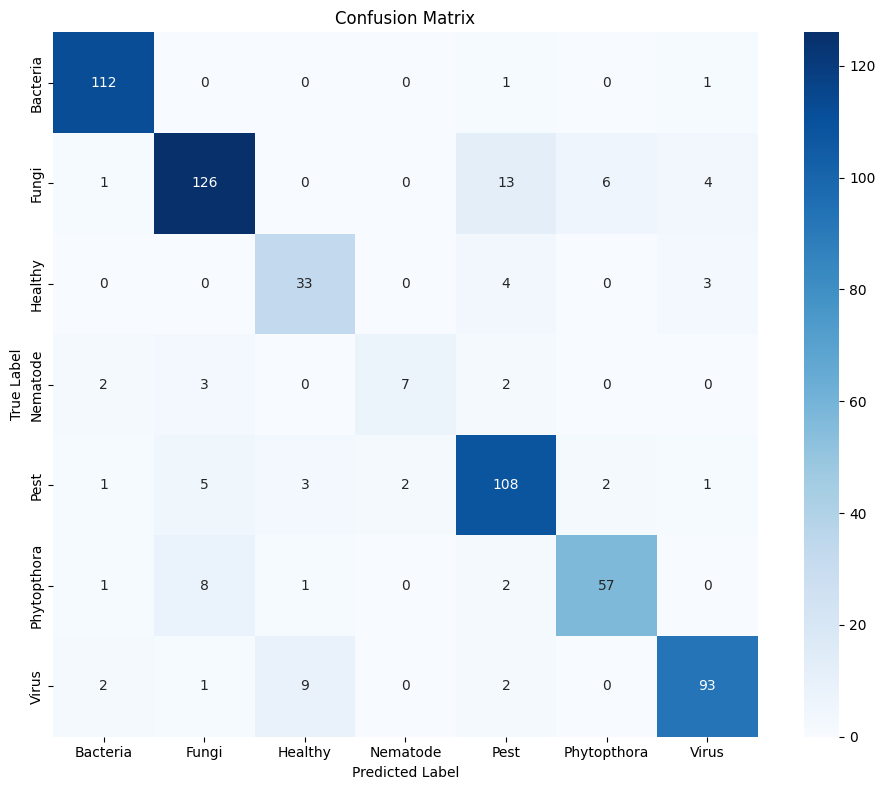

In [21]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True,
    square=True
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=300)
plt.show()